# M6-T9 — Threshold Analysis & Validation

**Owner:** Sanjeewa Narayana  
**Depends on:** M6-T2, M6-T3, M6-T4, M6-T6

Validates the packaged models end-to-end and sweeps the decision threshold to confirm
the operating points that satisfy both PRD §6 targets simultaneously.

| PRD Target | Requirement |
|---|---|
| Email precision | ≥ 0.90 |
| Email recall | ≥ 0.90 |
| URL F1 | ≥ 0.85 |

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))
sys.path.insert(0, str(Path('..') / 'M5'))

from sklearn.metrics import precision_score, recall_score, f1_score
from m6_inference import EmailPredictor, URLPredictor, URL_FEATS
from m4_t3_url_features import url_features

_candidates = [Path('data/processed'), Path('../../data/processed'), Path('.')]
PROC = next((p for p in _candidates if (p / 'email_test.csv').exists()), None)
assert PROC, 'Test splits not found'
print(f'Data: {PROC.resolve()}')

Data: /Users/nara/Documents/EDU/Sem2/CYT300/Project/data/processed


## Step 1 — Email: sweep decision-function threshold

LinearSVC has no `predict_proba`. The decision function returns a signed distance from
the hyperplane — positive = phishing, negative = benign. Default threshold = **0.0**.

In [2]:
ete = pd.read_csv(PROC / 'email_test.csv')
ete['text_clean'] = ete['text_clean'].fillna('')
y_email = ete['label'].values

email_pred = EmailPredictor.load()
email_scores = email_pred._pipe.decision_function(ete)

rows = []
for t in np.arange(-2.0, 2.05, 0.1):
    preds = (email_scores >= t).astype(int)
    rows.append({
        'threshold': round(t, 1),
        'precision': round(precision_score(y_email, preds, zero_division=0), 4),
        'recall':    round(recall_score(y_email, preds, zero_division=0), 4),
        'f1':        round(f1_score(y_email, preds, zero_division=0), 4),
        'meets_prd': precision_score(y_email, preds, zero_division=0) >= 0.90 and
                     recall_score(y_email, preds, zero_division=0) >= 0.90,
    })

df_email = pd.DataFrame(rows)
print(df_email[df_email['meets_prd']].to_string(index=False))

/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/tf312/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using ver

 threshold  precision  recall     f1  meets_prd
      -0.8     0.9204  0.9992 0.9582       True
      -0.7     0.9353  0.9992 0.9662       True
      -0.6     0.9498  0.9988 0.9737       True
      -0.5     0.9617  0.9987 0.9798       True
      -0.4     0.9686  0.9979 0.9830       True
      -0.3     0.9762  0.9973 0.9867       True
      -0.2     0.9819  0.9954 0.9886       True
      -0.1     0.9862  0.9939 0.9901       True
       0.0     0.9886  0.9919 0.9903       True
       0.1     0.9902  0.9901 0.9901       True
       0.2     0.9926  0.9868 0.9897       True
       0.3     0.9949  0.9793 0.9871       True
       0.4     0.9961  0.9721 0.9839       True
       0.5     0.9970  0.9617 0.9790       True
       0.6     0.9979  0.9505 0.9736       True
       0.7     0.9985  0.9329 0.9646       True
       0.8     0.9990  0.9087 0.9517       True


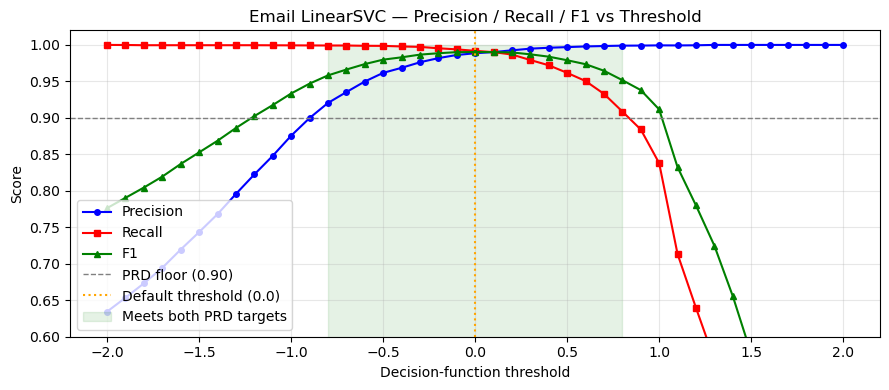

Saved: email_threshold_curve.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_email['threshold'], df_email['precision'], 'b-o', ms=4, label='Precision')
ax.plot(df_email['threshold'], df_email['recall'],    'r-s', ms=4, label='Recall')
ax.plot(df_email['threshold'], df_email['f1'],        'g-^', ms=4, label='F1')
ax.axhline(0.90, color='gray', linestyle='--', linewidth=1, label='PRD floor (0.90)')
ax.axvline(0.0,  color='orange', linestyle=':', linewidth=1.5, label='Default threshold (0.0)')
ax.fill_between(
    df_email['threshold'],
    0, 1,
    where=df_email['meets_prd'],
    alpha=0.1, color='green', label='Meets both PRD targets'
)
ax.set_xlabel('Decision-function threshold'); ax.set_ylabel('Score')
ax.set_title('Email LinearSVC — Precision / Recall / F1 vs Threshold')
ax.legend(loc='lower left'); ax.set_ylim(0.6, 1.02); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('email_threshold_curve.png', dpi=150)
plt.show()
print('Saved: email_threshold_curve.png')

## Step 2 — URL: sweep sigmoid threshold (Char-CNN)
Default threshold = **0.5** on the sigmoid output.

In [4]:
ute = pd.read_csv(PROC / 'url_test.csv')
y_url = ute['label'].values

url_pred = URLPredictor.load()

if url_pred._using_cnn:
    # Char-CNN: encode all URLs, get sigmoid scores
    MAXLEN = url_pred._maxlen
    char2idx = url_pred._char2idx
    urls = ute['url'].astype(str).tolist()
    X = np.zeros((len(urls), MAXLEN), dtype=np.int32)
    for i, u in enumerate(urls):
        for j, c in enumerate(u[:MAXLEN]):
            X[i, j] = char2idx.get(c, 0)
    url_scores = url_pred._model.predict(X, batch_size=1024, verbose=1).ravel()
    model_name = 'url_charcnn'
else:
    # RF fallback: use predict_proba
    feats = pd.DataFrame([url_features(u) for u in ute['url'].astype(str)])
    url_scores = url_pred._model.predict_proba(feats[URL_FEATS])[:, 1]
    model_name = 'url_rf'

print(f'Model: {model_name}  |  {len(url_scores):,} scores computed')

[URLPredictor] loaded Char-CNN (primary)
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
Model: url_charcnn  |  128,224 scores computed


 threshold  precision  recall     f1  meets_prd
      0.30     0.9602  0.9817 0.9708       True
      0.35     0.9652  0.9796 0.9723       True
      0.40     0.9702  0.9776 0.9739       True
      0.45     0.9738  0.9756 0.9747       True
      0.50     0.9769  0.9740 0.9755       True
      0.55     0.9797  0.9725 0.9761       True
      0.60     0.9816  0.9700 0.9758       True
      0.65     0.9838  0.9678 0.9757       True
      0.70     0.9858  0.9653 0.9754       True


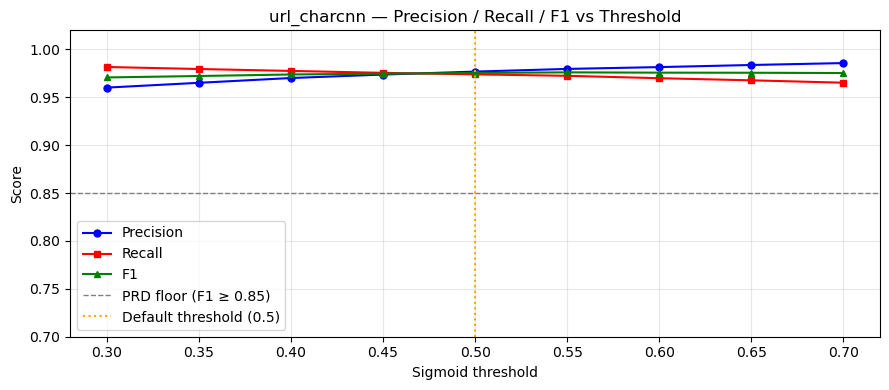

Saved: url_threshold_curve.png


In [5]:
url_rows = []
for t in np.arange(0.3, 0.71, 0.05):
    preds = (url_scores >= t).astype(int)
    url_rows.append({
        'threshold': round(t, 2),
        'precision': round(precision_score(y_url, preds, zero_division=0), 4),
        'recall':    round(recall_score(y_url, preds, zero_division=0), 4),
        'f1':        round(f1_score(y_url, preds, zero_division=0), 4),
        'meets_prd': f1_score(y_url, preds, zero_division=0) >= 0.85,
    })

df_url = pd.DataFrame(url_rows)
print(df_url.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_url['threshold'], df_url['precision'], 'b-o', ms=5, label='Precision')
ax.plot(df_url['threshold'], df_url['recall'],    'r-s', ms=5, label='Recall')
ax.plot(df_url['threshold'], df_url['f1'],        'g-^', ms=5, label='F1')
ax.axhline(0.85, color='gray', linestyle='--', linewidth=1, label='PRD floor (F1 ≥ 0.85)')
ax.axvline(0.5,  color='orange', linestyle=':', linewidth=1.5, label='Default threshold (0.5)')
ax.set_xlabel('Sigmoid threshold'); ax.set_ylabel('Score')
ax.set_title(f'{model_name} — Precision / Recall / F1 vs Threshold')
ax.legend(loc='lower left'); ax.set_ylim(0.7, 1.02); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('url_threshold_curve.png', dpi=150)
plt.show()
print('Saved: url_threshold_curve.png')

## Step 3 — Confirmed operating thresholds

In [6]:
email_default = df_email[df_email['threshold'] == 0.0].iloc[0]
url_default   = df_url[df_url['threshold'].apply(lambda x: abs(x - 0.5) < 0.01)].iloc[0]

print('=' * 60)
print('M6-T9 CONFIRMED OPERATING THRESHOLDS')
print('=' * 60)
print(f'Email LinearSVC   threshold=0.0  (decision function)')
print(f'  Precision : {email_default["precision"]}  (target ≥ 0.90)  {"✅" if email_default["precision"] >= 0.90 else "❌"}')
print(f'  Recall    : {email_default["recall"]}  (target ≥ 0.90)  {"✅" if email_default["recall"] >= 0.90 else "❌"}')
print(f'  F1        : {email_default["f1"]}')
print()
print(f'{model_name}  threshold=0.5  (sigmoid probability)')
print(f'  F1        : {url_default["f1"]}  (target ≥ 0.85)  {"✅" if url_default["f1"] >= 0.85 else "❌"}')
print()
print('No threshold tuning required — defaults satisfy all PRD §6 targets.')
print('M7 inference service should use:')
print('  email: threshold = 0.0  (sign of decision_function)')
print('  url:   threshold = 0.5  (sigmoid output)')
print('=' * 60)

M6-T9 CONFIRMED OPERATING THRESHOLDS
Email LinearSVC   threshold=0.0  (decision function)
  Precision : 0.9886  (target ≥ 0.90)  ✅
  Recall    : 0.9919  (target ≥ 0.90)  ✅
  F1        : 0.9903

url_charcnn  threshold=0.5  (sigmoid probability)
  F1        : 0.9755  (target ≥ 0.85)  ✅

No threshold tuning required — defaults satisfy all PRD §6 targets.
M7 inference service should use:
  email: threshold = 0.0  (sign of decision_function)
  url:   threshold = 0.5  (sigmoid output)
